In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    "Text": [
        "I really enjoyed this product",
        "The service was excellent",
        "This is an amazing experience",
        "I am very happy with the result",
        "The product is good",
        "I love this product",
        "The quality is excellent",
        "Very happy with the service",
        "This product is fantastic",
        "I am satisfied with the result",

        "I did not like this product",
        "The service was terrible",
        "This was a bad experience",
        "I am disappointed with the result",
        "The product is poor",
        "I hate this product",
        "The quality is terrible",
        "Very unhappy with the service",
        "This product is awful",
        "I am dissatisfied with the result",

        "It is okay, nothing special",
        "The experience was average",
        "The product is normal",
        "The service was okay",
        "It is neither good nor bad",
        "The result is average",
        "The quality is acceptable",
        "Nothing special about this product",
        "The experience was fine",
        "The service was normal"
    ],

    "Sentiment": [
        "Positive", "Positive", "Positive", "Positive", "Positive",
        "Positive", "Positive", "Positive", "Positive", "Positive",

        "Negative", "Negative", "Negative", "Negative", "Negative",
        "Negative", "Negative", "Negative", "Negative", "Negative",

        "Neutral", "Neutral", "Neutral", "Neutral", "Neutral",
        "Neutral", "Neutral", "Neutral", "Neutral", "Neutral"
    ]
}

df = pd.DataFrame(data)

print("Total Reviews:", len(df))
df

Total Reviews: 30


,Text,Sentiment
0,I really enjoyed this product,Positive
1,The service was excellent,Positive
2,This is an amazing experience,Positive
3,I am very happy with the result,Positive
4,The product is good,Positive
5,I love this product,Positive
6,The quality is excellent,Positive
7,Very happy with the service,Positive
8,This product is fantastic,Positive
9,I am satisfied with the result,Positive


In [3]:
sentiment_count = df["Sentiment"].value_counts()

print(sentiment_count)

Sentiment
Positive    10
Negative    10
Neutral     10
Name: count, dtype: int64


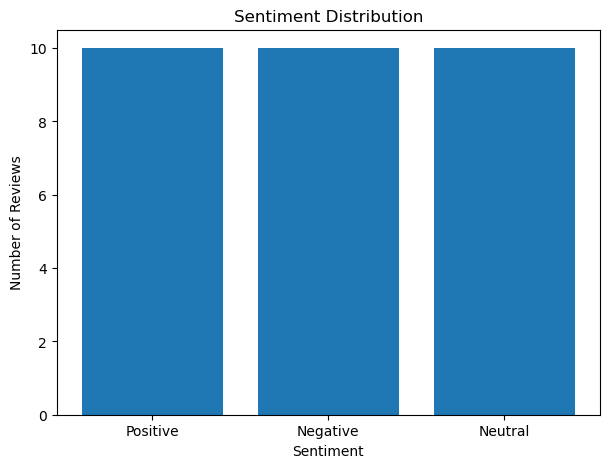

In [4]:
plt.figure(figsize=(7, 5))

plt.bar(sentiment_count.index, sentiment_count.values)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["Text"])

print("Text converted into numerical features!")
print("Shape:", X.shape)

Text converted into numerical features!
Shape: (30, 44)


In [6]:
from sklearn.model_selection import train_test_split

y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 24
Testing samples: 6


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Sentiment model trained successfully!")

Sentiment model trained successfully!


In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Model Accuracy: 16.67 %

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
     Neutral       0.33      0.50      0.40         2
    Positive       0.00      0.00      0.00         2

    accuracy                           0.17         6
   macro avg       0.11      0.17      0.13         6
weighted avg       0.11      0.17      0.13         6



In [9]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results)

     Actual Predicted
0  Positive   Neutral
1   Neutral  Positive
2  Positive   Neutral
3  Negative  Positive
4   Neutral   Neutral
5  Negative  Positive


In [10]:
new_reviews = [
    "I love the excellent service",
    "This product is terrible",
    "The experience was okay"
]

new_X = vectorizer.transform(new_reviews)

predictions = model.predict(new_X)

for review, sentiment in zip(new_reviews, predictions):
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print()

Review: I love the excellent service
Predicted Sentiment: Positive

Review: This product is terrible
Predicted Sentiment: Negative

Review: The experience was okay
Predicted Sentiment: Neutral



In [11]:
print("========== SENTIMENT ANALYSIS REPORT ==========")
print()

print("Total Reviews:", len(df))
print("Positive Reviews:", (df["Sentiment"] == "Positive").sum())
print("Negative Reviews:", (df["Sentiment"] == "Negative").sum())
print("Neutral Reviews:", (df["Sentiment"] == "Neutral").sum())
print("Model Test Accuracy:", round(accuracy * 100, 2), "%")

print()
print("========== KEY INSIGHTS ==========")
print("1. The dataset contains 30 customer reviews.")
print("2. The dataset has Positive, Negative and Neutral sentiments.")
print("3. The model can classify new text reviews.")
print("4. Three sample reviews were successfully predicted.")
print("5. A larger real-world dataset can improve model performance.")

========== SENTIMENT ANALYSIS REPORT ==========

Total Reviews: 30
Positive Reviews: 10
Negative Reviews: 10
Neutral Reviews: 10
Model Test Accuracy: 16.67 %

========== KEY INSIGHTS ==========
1. The dataset contains 30 customer reviews.
2. The dataset has Positive, Negative and Neutral sentiments.
3. The model can classify new text reviews.
4. Three sample reviews were successfully predicted.
5. A larger real-world dataset can improve model performance.
